# **Notebook to create figures and tables from the benchmarking experiment**

Will create ressource consumption summaries

In [ ]:
# Imports
import os
import re

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
def parse_memory(value):
    """
    Convert Nextflow memory strings to GB.
    Examples:
    12.3 GB
    512 MB
    1.4 TB
    """
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    try:
        num, unit = value.split()

        num = float(num)

        unit = unit.upper()

        if unit.startswith("KB"):
            return num / 1024**2
        elif unit.startswith("MB"):
            return num / 1024
        elif unit.startswith("GB"):
            return num

    except Exception:
        pass

    return np.nan

def parse_runtime(value):
    """
    Convert Nextflow runtime strings to minutes.
    """

    value = str(value)

    total = 0

    patterns = {
        "d": 24 * 60,
        "h": 60,
        "m": 1,
        "s": 1 / 60,
    }

    for unit, factor in patterns.items():
        match = re.search(rf"(\d+)\s*{unit}", value)
        if match:
            total += int(match.group(1)) * factor

    return total

In [2]:
# Set root Dir for the project.
ROOT_DIR = "/Users/anthonygagnon/Documents/École/Université/Projects/nf-pediatric/"
RESULTS_DIR = ROOT_DIR + "RessourcesAnalysis/"
REPOSITORY = "/Users/anthonygagnon/code/nf-pediatric-paper/"

# Create a directory for the results if it doesn't exist
if not os.path.exists(RESULTS_DIR):
    os.makedirs(RESULTS_DIR)

In [29]:
# Fetch Harding font.
font_files = []
for fontpath in font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
    if "Harding".lower() in fontpath.lower():
        font_files.append(fontpath)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# Set Harding font.
plt.rcParams['font.family'] = 'Harding Text Web'

# Set the Set2 color palette as an iterable.
cmap = sns.color_palette("Set2", 8)

In [43]:
# Load the data containing the median and CI for each module
df = pd.read_csv(RESULTS_DIR + "trace_fixed.txt", sep="\t")

df["memory_gb"] = df["rss"].apply(parse_memory)
df["runtime_min"] = df["duration"].apply(parse_runtime)
df["process"] = df["name"].str.replace(r"\s+\(.*\)$", "", regex=True)

# List of process to exclude, as not part of the main workflow (adds-on, like registration to template)
exclude_processes = [
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:UTILS_TEMPLATEFLOW",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:MASK_T1W",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:MASK_T2W",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:BET_T1W",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:BET_T2W",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:REGISTRATION_ANTS",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:WARPIMAGES",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:WARPRGB",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:WARPMASK",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:WARPLABELS",
    "SCILUS_SF_PEDIATRIC:SF_PEDIATRIC:OUTPUT_TEMPLATE_SPACE:REGISTRATION_TRACTOGRAM"
]
df = df[~df["process"].isin(exclude_processes)].copy()

# Keep only strings after the last ":" in the process name
df["process"] = df["process"].str.split(":").str[-1].str.strip()

/var/folders/23/p0fh1nrd473dtfz3cx_4g0j00000gn/T/ipykernel_95266/2412752799.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(axs[2].get_xticklabels(), fontsize=12, rotation=90, ha="center", va="top")


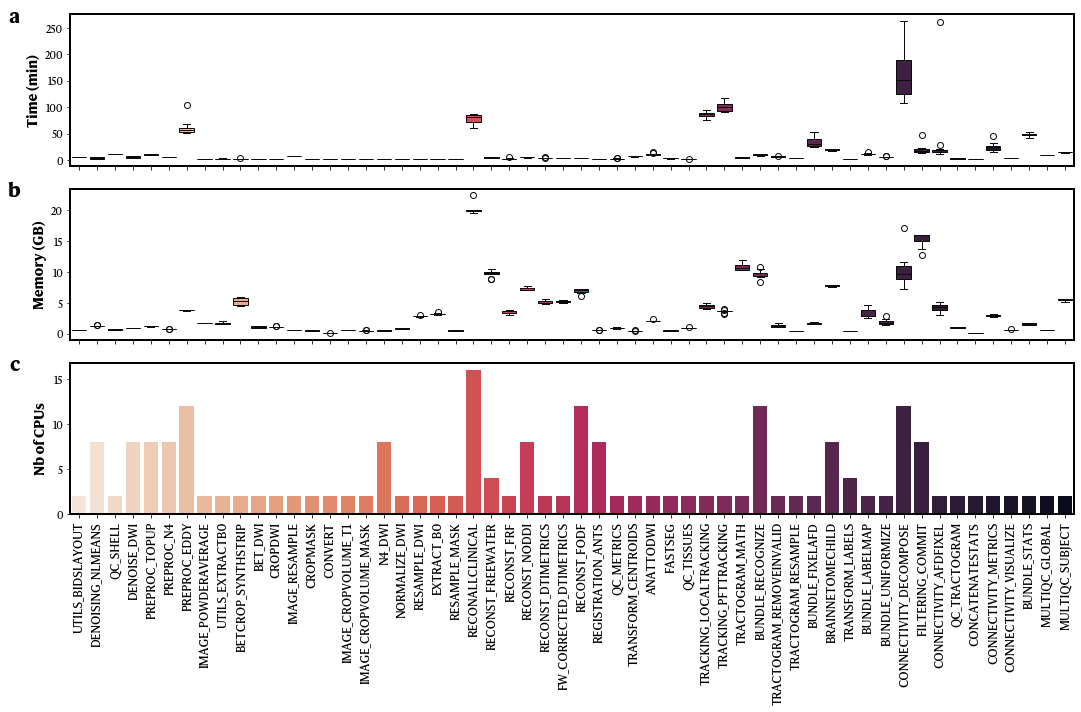

In [60]:
# Plot the time spent on each module, with error bars for the confidence intervals as box plot
plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axs = plt.gcf().get_axes()
sns.boxplot(x="process", y="runtime_min", data=df, hue="process", palette="rocket_r", ax=axs[0])
# Add error bars for the confidence intervals
#axs[0].set_title("Time Spent on Each Module (with CI)", fontsize=16)
#axs[0].set_xlabel("Module", fontsize=14)
axs[0].set_ylabel("Time (min)", fontsize=14, fontweight="bold")
#axs[0].set_xticklabels(axs[0].get_xticklabels(), fontsize=8, rotation=90, ha="center", va="top")
# DO a y-log scale
#axs[0].set_yscale("log")
axs[0].spines[["top", "bottom", "left", "right"]].set_linewidth(2)

# memory usage
sns.boxplot(x="process", y="memory_gb", data=df, hue="process", palette="rocket_r", ax=axs[1])
#axs[1].set_title("Memory Usage of Each Module (with CI)", fontsize=16)
axs[1].set_xlabel("", fontsize=14)
axs[1].set_ylabel("Memory (GB)", fontsize=14, fontweight="bold")
#axs[1].set_xticklabels(axs[1].get_xticklabels(), fontsize=12, rotation=90, ha="center", va="top")
#axs[1].set_yscale("log")
axs[1].spines[["top", "bottom", "left", "right"]].set_linewidth(2)

# CPU usage
sns.barplot(x="process", y="cpus", data=df, hue="process", palette="rocket_r", ax=axs[2])
#axs[2].set_title("CPU Usage of Each Module (with CI)", fontsize=16)
axs[2].set_xlabel("", fontsize=14, fontweight="bold")
axs[2].set_ylabel("Nb of CPUs", fontsize=14, fontweight="bold")
axs[2].set_xticklabels(axs[2].get_xticklabels(), fontsize=12, rotation=90, ha="center", va="top")
#axs[2].set_yscale("log")
axs[2].spines[["top", "bottom", "left", "right"]].set_linewidth(2)
# Set yticks to integers only
axs[2].yaxis.get_major_locator().set_params(integer=True)

# Add a, b to the top left of each subplot
axs[0].text(-0.05, 1.05, "a", transform=axs[0].transAxes, fontsize=20, fontweight="bold", va="top", ha="right")
axs[1].text(-0.05, 1.05, "b", transform=axs[1].transAxes, fontsize=20, fontweight="bold", va="top", ha="right")
axs[2].text(-0.05, 1.05, "c", transform=axs[2].transAxes, fontsize=20, fontweight="bold", va="top", ha="right")

plt.tight_layout()